# Optativa III: Ciencia de Datos
## Actividad práctica — Pruebas de hipótesis para comparar grupos

**Universidad de Especialidades UNE · Plantel Centro**
**Ingeniería en Computación · 9.º semestre · Semana 3 · Sesión 1**

---

### Propósito

En esta actividad aplicarás las **pruebas de hipótesis** más usadas en ciencia de datos para **comparar grupos** dentro de un dataset real:

- **Prueba t** — comparar las medias de dos grupos.
- **ANOVA** — comparar las medias de tres o más grupos.
- **Prueba chi-cuadrada** — evaluar si dos variables categóricas están asociadas.

Además analizarás el **p-valor**, los **errores tipo I y II**, y el efecto del **tamaño de muestra en datos masivos**.

Harás **dos ejercicios por cada prueba** y responderás **20 preguntas** modificando e interpretando el código, más **6 preguntas finales de análisis integrador**.

### El repositorio de datos

Usaremos el dataset **`tips`**, un repositorio **público** con **244 registros reales** de las propinas de un restaurante. Está incluido en la librería `seaborn` (preinstalada en Google Colab), así que **todos** pueden cargarlo sin descargar nada.

### Cómo trabajar en Google Colab

1. Abre este cuaderno en [Google Colab](https://colab.research.google.com).
2. Ejecuta cada celda con **Shift + Enter**, en orden.
3. Responde las preguntas (doble clic para editar) y completa los retos.
4. Al terminar: **Archivo → Guardar una copia en Drive** y entrega el enlace en Classroom.


---
## Paso 0 — Preparación y carga del repositorio


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)

# Cargamos el repositorio publico (incluido en seaborn / Colab)
df = sns.load_dataset("tips")

# Creamos una variable util: el porcentaje de propina sobre la cuenta
df["tip_pct"] = df["tip"] / df["total_bill"] * 100

print("Dimensiones:", df.shape)
print("\nGrupos disponibles para comparar:")
for col in ["sex", "smoker", "day", "time"]:
    print(f"  {col}: {df[col].value_counts().to_dict()}")
df.head()

Dimensiones: (244, 8)

Grupos disponibles para comparar:
  sex: {'Male': 157, 'Female': 87}
  smoker: {'No': 151, 'Yes': 93}
  day: {'Sat': 87, 'Sun': 76, 'Thur': 62, 'Fri': 19}
  time: {'Dinner': 176, 'Lunch': 68}


,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765


> **Pregunta 1** — ¿Qué representa la variable `tip_pct` que creamos? ¿Por qué puede ser más justa para comparar propinas entre grupos que la propina en dólares (`tip`)?

**Respuesta:** `tip_pct` es la propina expresada como **porcentaje de la cuenta total** (propina ÷ cuenta × 100). Es más justa porque la propina en dólares depende del tamaño de la cuenta: una mesa que gastó \$50 casi siempre deja más dólares que una que gastó \$10, aunque ambas dejen el mismo 15%. Al normalizar por la cuenta, comparamos la **generosidad relativa** de cada grupo y no cuánto consumieron.

> **Pregunta 2** — Enumera qué variables del dataset son **categóricas** (sirven para formar grupos) y cuáles son **numéricas** (sirven para comparar medias). ¿Por qué esta distinción decide qué prueba usar?

**Respuesta:** Categóricas: `sex`, `smoker`, `day`, `time`. Numéricas: `total_bill`, `tip`, `size`, `tip_pct`. La distinción decide la prueba porque cada una contrasta cosas distintas: si comparo una **variable numérica entre 2 grupos** uso prueba **t**; entre **3 o más grupos**, **ANOVA**; y si quiero saber si **dos variables categóricas** están asociadas, **chi-cuadrada** sobre su tabla de contingencia.


---
## Marco conceptual — Cómo se lee una prueba de hipótesis

Toda prueba de hipótesis contrasta:
- **H₀ (hipótesis nula):** no hay diferencia / no hay asociación.
- **H₁ (hipótesis alternativa):** sí hay diferencia / sí hay asociación.

Regla de decisión con el **p-valor** y un nivel de significancia α (por convención 0.05):
- Si **p < 0.05** → se **rechaza H₀** (la diferencia es estadísticamente significativa).
- Si **p ≥ 0.05** → **no se rechaza H₀** (no hay evidencia suficiente de diferencia).


In [2]:
# Funcion auxiliar que interpreta un p-valor de forma consistente
def interpretar(p, alpha=0.05):
    if p < alpha:
        return f"p = {p:.4f} < {alpha}  ->  SE RECHAZA H0 (diferencia significativa)"
    else:
        return f"p = {p:.4f} >= {alpha}  ->  NO se rechaza H0 (sin evidencia de diferencia)"

# Prueba rapida de la funcion
print(interpretar(0.0032))
print(interpretar(0.4100))

p = 0.0032 < 0.05  ->  SE RECHAZA H0 (diferencia significativa)
p = 0.4100 >= 0.05  ->  NO se rechaza H0 (sin evidencia de diferencia)


> **Pregunta 3** — Con tus palabras, ¿qué significa exactamente "rechazar H₀"? ¿Es lo mismo que "demostrar que H₁ es verdadera al 100%"? Explica.

**Respuesta:** Rechazar H₀ significa que, **si H₀ fuera cierta**, los datos que observamos serían muy improbables (p < α); por eso decidimos que la evidencia está en contra de H₀. **No** es demostrar H₁ al 100%: es una decisión bajo incertidumbre. Siempre queda la posibilidad de estar cometiendo un **error tipo I** (rechazar una H₀ que en realidad era cierta), cuya probabilidad controlamos con α (5%). La estadística no demuestra: **acumula evidencia**.


---
# TEMA 1 — Prueba t (comparar dos grupos)

La prueba t compara las **medias de dos grupos** y determina si su diferencia es estadísticamente significativa. Usamos `stats.ttest_ind`.

## Ejercicio 1.1 — ¿Hombres y mujeres dejan distinto porcentaje de propina?


Propina media hombres: 15.77%  (n=157)
Propina media mujeres: 16.65%  (n=87)

Estadistico t = -1.143
p = 0.2542 >= 0.05  ->  NO se rechaza H0 (sin evidencia de diferencia)


<Figure size 800x500 with 0 Axes>

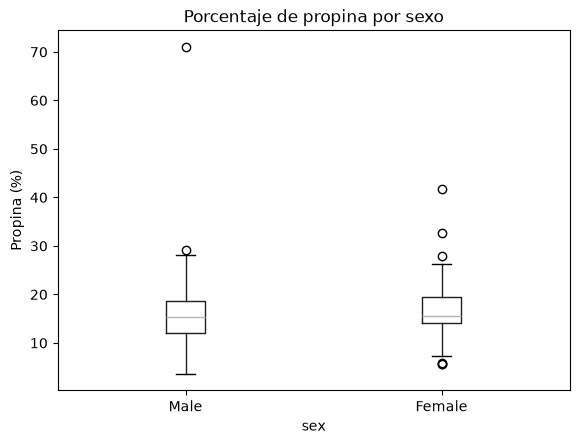

In [3]:
# H0: la media de tip_pct es igual en hombres y mujeres
# H1: las medias son distintas
grupo_h = df[df["sex"] == "Male"]["tip_pct"]
grupo_m = df[df["sex"] == "Female"]["tip_pct"]

print(f"Propina media hombres: {grupo_h.mean():.2f}%  (n={len(grupo_h)})")
print(f"Propina media mujeres: {grupo_m.mean():.2f}%  (n={len(grupo_m)})")
print()

# Prueba t para muestras independientes (Welch, no asume varianzas iguales)
t_stat, p_val = stats.ttest_ind(grupo_h, grupo_m, equal_var=False)
print(f"Estadistico t = {t_stat:.3f}")
print(interpretar(p_val))

# Visualizacion
plt.figure(figsize=(8,5))
df.boxplot(column="tip_pct", by="sex", grid=False)
plt.title("Porcentaje de propina por sexo"); plt.suptitle("")
plt.ylabel("Propina (%)"); plt.show()

> **Pregunta 4** — Según el p-valor, ¿hombres y mujeres dejan un porcentaje de propina significativamente distinto? Escribe la conclusión en términos del negocio (¿debería el restaurante tratar distinto a cada grupo?).

**Respuesta:** No. El p-valor fue **0.2542 ≥ 0.05**, así que **no se rechaza H₀**: la diferencia observada (15.77% hombres vs 16.65% mujeres) es compatible con el azar. En términos de negocio: **no hay evidencia** para tratar distinto a hombres y mujeres; diseñar promociones o asignar meseros según el sexo del cliente no tiene respaldo en los datos.

> **Pregunta 5** — Observa el boxplot. Las medias son parecidas pero no idénticas. ¿Por qué una diferencia numérica pequeña puede NO ser estadísticamente significativa? Relaciónalo con la variabilidad dentro de cada grupo.

**Respuesta:** Porque la significancia no depende solo del tamaño de la diferencia entre medias, sino de esa diferencia **en relación con la variabilidad interna** de cada grupo y el tamaño de muestra. En el boxplot las dos cajas se **traslapan casi por completo**: dentro de cada grupo hay propinas desde ~5% hasta ~25%. Una diferencia de 0.9 puntos entre medias es diminuta comparada con esa dispersión, así que perfectamente pudo surgir por azar al muestrear.


## Ejercicio 1.2 — ¿Los fumadores gastan más en la cuenta total?


In [4]:
# H0: la media de total_bill es igual en fumadores y no fumadores
# H1: las medias son distintas
fuma    = df[df["smoker"] == "Yes"]["total_bill"]
no_fuma = df[df["smoker"] == "No"]["total_bill"]

print(f"Cuenta media fumadores:    ${fuma.mean():.2f}  (n={len(fuma)})")
print(f"Cuenta media no fumadores: ${no_fuma.mean():.2f}  (n={len(no_fuma)})")
print()

t_stat2, p_val2 = stats.ttest_ind(fuma, no_fuma, equal_var=False)
print(f"Estadistico t = {t_stat2:.3f}")
print(interpretar(p_val2))

Cuenta media fumadores:    $20.76  (n=93)
Cuenta media no fumadores: $19.19  (n=151)

Estadistico t = 1.284
p = 0.2008 >= 0.05  ->  NO se rechaza H0 (sin evidencia de diferencia)


> **Pregunta 6** — ¿Hay una diferencia significativa en la cuenta total entre fumadores y no fumadores? Reporta el p-valor y tu conclusión.

**Respuesta:** No. Los fumadores gastan en promedio \$20.76 y los no fumadores \$19.19, pero el p-valor fue **0.2008 ≥ 0.05**, así que **no se rechaza H₀**: no hay evidencia de que fumadores y no fumadores gasten distinto; la diferencia de ~\$1.57 es atribuible al azar muestral.


### Reto de código 1

Haz tú una prueba t que compare la **propina en dólares** (`tip`, no el porcentaje) entre **cena y comida** (`time`: Dinner vs Lunch). Escribe H₀, ejecuta la prueba e interpreta.


In [5]:
# RETO 1 resuelto: prueba t para 'tip' entre Dinner y Lunch
# H0: la propina media (en dolares) es igual en cena y comida
# H1: las medias son distintas
cena   = df[df["time"] == "Dinner"]["tip"]
comida = df[df["time"] == "Lunch"]["tip"]

print(f"Propina media en cena:   ${cena.mean():.2f}  (n={len(cena)})")
print(f"Propina media en comida: ${comida.mean():.2f}  (n={len(comida)})")
print()

t3, p3 = stats.ttest_ind(cena, comida, equal_var=False)
print(f"Estadistico t = {t3:.3f}")
print(interpretar(p3))

Propina media en cena:   $3.10  (n=176)
Propina media en comida: $2.73  (n=68)

Estadistico t = 2.059
p = 0.0413 < 0.05  ->  SE RECHAZA H0 (diferencia significativa)


> **Pregunta 7** — Reporta el resultado de tu reto: ¿la propina en dólares difiere entre cena y comida? ¿Qué explicación de negocio se te ocurre para ese resultado?

**Respuesta:** Sí difiere: en la cena se deja en promedio \$3.10 y en la comida \$2.73, con **p = 0.0413 < 0.05** → se rechaza H₀. Explicación de negocio: en la cena las cuentas son más grandes (más platillos, bebidas, salidas de fin de semana en grupo), y como la propina suele calcularse como porcentaje de la cuenta, **a mayor consumo, más dólares de propina** aunque la generosidad relativa (el %) sea la misma.


---
# TEMA 2 — ANOVA (comparar tres o más grupos)

Cuando hay **más de dos grupos**, no se hacen muchas pruebas t (eso infla el error). Se usa **ANOVA**, que compara todas las medias a la vez con `stats.f_oneway`.

## Ejercicio 2.1 — ¿El porcentaje de propina cambia según el día de la semana?


Propina media (%) por dia:
  Sun: 16.69%  (n=76)
  Sat: 15.32%  (n=87)
  Thur: 16.13%  (n=62)
  Fri: 16.99%  (n=19)

Estadistico F = 0.848
p = 0.4688 >= 0.05  ->  NO se rechaza H0 (sin evidencia de diferencia)


<Figure size 800x500 with 0 Axes>

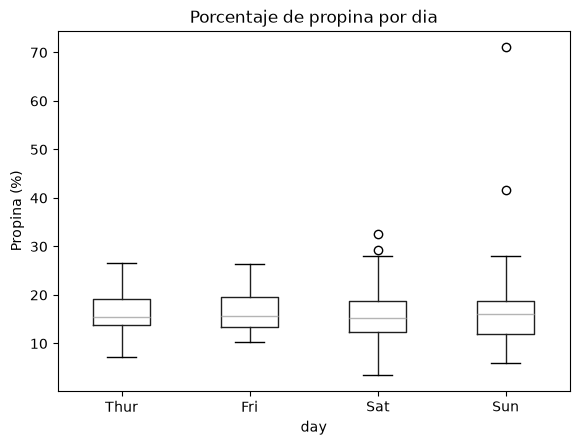

In [6]:
# H0: la media de tip_pct es igual en los 4 dias
# H1: al menos un dia tiene media distinta
dias = df["day"].unique()
grupos_dia = [df[df["day"] == d]["tip_pct"] for d in dias]

print("Propina media (%) por dia:")
for d in dias:
    sub = df[df["day"] == d]["tip_pct"]
    print(f"  {d}: {sub.mean():.2f}%  (n={len(sub)})")
print()

F_stat, p_anova = stats.f_oneway(*grupos_dia)
print(f"Estadistico F = {F_stat:.3f}")
print(interpretar(p_anova))

plt.figure(figsize=(8,5))
df.boxplot(column="tip_pct", by="day", grid=False)
plt.title("Porcentaje de propina por dia"); plt.suptitle("")
plt.ylabel("Propina (%)"); plt.show()

> **Pregunta 8** — ¿El día de la semana influye significativamente en el porcentaje de propina? ¿Qué dice el p-valor?

**Respuesta:** No. Las medias por día van de 15.32% (sábado) a 16.99% (viernes), pero el ANOVA dio F = 0.848 con **p = 0.4688 ≥ 0.05** → no se rechaza H₀. El porcentaje de propina se mantiene estable (~16%) sin importar el día: las pequeñas diferencias entre días son explicables por azar.

> **Pregunta 9** — ¿Por qué NO sería correcto comparar los 4 días haciendo 6 pruebas t (una por cada par)? (Pista: piensa en el error tipo I acumulándose con cada prueba.)

**Respuesta:** Porque cada prueba t tiene un 5% de probabilidad de dar un falso positivo, y ese riesgo **se acumula** con cada comparación. Con 6 pruebas, la probabilidad de que al menos una salga "significativa" por puro azar es 1 − 0.95⁶ ≈ **26%**, muy por encima del 5% prometido. El ANOVA evita esa inflación haciendo **una sola prueba global** que compara todas las medias a la vez manteniendo α = 0.05.


## Ejercicio 2.2 — ¿La cuenta total cambia según el día?


In [7]:
# H0: la media de total_bill es igual en los 4 dias
grupos_bill = [df[df["day"] == d]["total_bill"] for d in dias]

print("Cuenta media por dia:")
for d in dias:
    sub = df[df["day"] == d]["total_bill"]
    print(f"  {d}: ${sub.mean():.2f}  (n={len(sub)})")
print()

F2, p_anova2 = stats.f_oneway(*grupos_bill)
print(f"Estadistico F = {F2:.3f}")
print(interpretar(p_anova2))

Cuenta media por dia:
  Sun: $21.41  (n=76)
  Sat: $20.44  (n=87)
  Thur: $17.68  (n=62)
  Fri: $17.15  (n=19)

Estadistico F = 2.767
p = 0.0425 < 0.05  ->  SE RECHAZA H0 (diferencia significativa)


> **Pregunta 10** — Este resultado suele dar significativo mientras que el del porcentaje de propina no. ¿Qué te dice esto? (Una cosa cambia entre días —cuánto se gasta— y otra no —qué proporción se deja de propina.)

**Respuesta:** Efectivamente: la cuenta total sí difiere entre días (F = 2.767, **p = 0.0425 < 0.05**; el fin de semana se gasta ~\$21 vs ~\$17 entre semana), mientras que el porcentaje de propina no (p = 0.4688). Esto separa dos comportamientos distintos del cliente: **cuánto consume** depende del día (salidas de fin de semana más grandes y caras), pero **qué proporción deja de propina** es un hábito cultural estable (~16%) que no cambia con el día.

> **Pregunta 11** — Un ANOVA significativo te dice que "al menos un grupo difiere", pero NO cuál. ¿Qué harías después para saber exactamente qué día es distinto? (Investiga el término "pruebas post-hoc".)

**Respuesta:** Aplicaría una **prueba post-hoc**, típicamente **Tukey HSD** (`pairwise_tukeyhsd` de `statsmodels`), que compara todos los pares de días **corrigiendo el error tipo I acumulado** para que el conjunto de comparaciones mantenga α = 0.05. Otra opción es hacer pruebas t por pares con **corrección de Bonferroni** (dividir α entre el número de comparaciones). Así se identifica exactamente qué día(s) difieren, por ejemplo domingo vs jueves.


### Reto de código 2

Ejecuta un ANOVA para comparar el **tamaño del grupo** (`size`) entre los cuatro días. ¿Se sientan grupos más grandes en ciertos días?


In [8]:
# RETO 2 resuelto: ANOVA de 'size' por dia
# H0: el tamano medio del grupo es igual en los 4 dias
# H1: al menos un dia tiene grupos de tamano distinto
grupos_size = [df[df["day"] == d]["size"] for d in dias]

print("Tamano medio del grupo por dia:")
for d in dias:
    sub = df[df["day"] == d]["size"]
    print(f"  {d}: {sub.mean():.2f} personas  (n={len(sub)})")
print()

F4, p4 = stats.f_oneway(*grupos_size)
print(f"Estadistico F = {F4:.3f}")
print(interpretar(p4))

Tamano medio del grupo por dia:
  Sun: 2.84 personas  (n=76)
  Sat: 2.52 personas  (n=87)
  Thur: 2.45 personas  (n=62)
  Fri: 2.11 personas  (n=19)

Estadistico F = 4.151
p = 0.0068 < 0.05  ->  SE RECHAZA H0 (diferencia significativa)


> **Pregunta 12** — Reporta el resultado de tu reto e interprétalo en el contexto del restaurante (por ejemplo, para planear personal según el día).

**Respuesta:** El ANOVA dio F = 4.151 con **p = 0.0068 < 0.05** → se rechaza H₀: el tamaño del grupo **sí** cambia según el día. El domingo llegan los grupos más grandes (2.84 personas en promedio) y el viernes los más chicos (2.11). Para el restaurante: los domingos conviene **más personal, mesas grandes disponibles y cocina preparada para volumen familiar**, mientras que el viernes dominan mesas de 2 (parejas), lo que sugiere otra distribución del salón y del menú.


---
# TEMA 3 — Prueba chi-cuadrada (asociación entre categorías)

La prueba chi-cuadrada evalúa si **dos variables categóricas están asociadas** (dependientes) o son independientes. Se construye una **tabla de contingencia** y se usa `stats.chi2_contingency`.

## Ejercicio 3.1 — ¿El sexo está asociado con ser fumador?


In [9]:
# H0: sexo y condicion de fumador son INDEPENDIENTES
# H1: estan asociados
tabla = pd.crosstab(df["sex"], df["smoker"])
print("Tabla de contingencia (observada):")
print(tabla)
print()

chi2, p_chi, dof, esperados = stats.chi2_contingency(tabla)
print(f"Estadistico chi2 = {chi2:.3f}   (grados de libertad = {dof})")
print(interpretar(p_chi))

Tabla de contingencia (observada):
smoker  Yes  No
sex            
Male     60  97
Female   33  54

Estadistico chi2 = 0.000   (grados de libertad = 1)
p = 1.0000 >= 0.05  ->  NO se rechaza H0 (sin evidencia de diferencia)


> **Pregunta 13** — ¿El sexo y el hábito de fumar están asociados o son independientes en este restaurante? Interpreta el p-valor.

**Respuesta:** Son **independientes**: chi² ≈ 0.000 con **p = 1.0 ≥ 0.05** → no se rechaza H₀. La proporción de fumadores es prácticamente la misma entre hombres (60/157 ≈ 38%) y mujeres (33/87 ≈ 38%): saber el sexo de un cliente no aporta información sobre si fuma o no.

> **Pregunta 14** — La prueba compara las frecuencias **observadas** con las **esperadas** bajo independencia (guardadas en `esperados`). Imprime `esperados` en una celda nueva y explica qué representarían esas cifras si H₀ fuera cierta.

**Respuesta:** (Celda siguiente.) Las frecuencias esperadas son los conteos que **veríamos si la independencia fuera exacta**, repartiendo los totales de fila y columna proporcionalmente: p. ej. 59.8 hombres fumadores esperados vs 60 observados. Como observado y esperado casi coinciden en las cuatro celdas, el estadístico chi² es ~0 y el p-valor es 1: los datos son exactamente lo que la independencia predice.


In [10]:
# Pregunta 14: frecuencias esperadas bajo H0 (independencia)
print("Frecuencias esperadas si sexo y fumar fueran independientes:")
print(pd.DataFrame(esperados, index=tabla.index, columns=tabla.columns).round(1))
print()
print("Observadas (para comparar):")
print(tabla)

Frecuencias esperadas si sexo y fumar fueran independientes:
smoker   Yes    No
sex               
Male    59.8  97.2
Female  33.2  53.8

Observadas (para comparar):
smoker  Yes  No
sex            
Male     60  97
Female   33  54


## Ejercicio 3.2 — ¿El día está asociado con el momento (comida/cena)?


In [11]:
# H0: dia y time son independientes
tabla2 = pd.crosstab(df["day"], df["time"])
print("Tabla de contingencia (dia x time):")
print(tabla2)
print()

chi2b, p_chi2, dof2, esp2 = stats.chi2_contingency(tabla2)
print(f"Estadistico chi2 = {chi2b:.3f}   (grados de libertad = {dof2})")
print(interpretar(p_chi2))

Tabla de contingencia (dia x time):
time  Lunch  Dinner
day                
Thur     61       1
Fri       7      12
Sat       0      87
Sun       0      76

Estadistico chi2 = 217.113   (grados de libertad = 3)
p = 0.0000 < 0.05  ->  SE RECHAZA H0 (diferencia significativa)


> **Pregunta 15** — Este resultado da fuertemente significativo. Mirando la tabla de contingencia, ¿por qué es tan obvia la asociación entre día y momento? (Observa en qué días hay comidas y en cuáles solo cenas.)

**Respuesta:** Porque la tabla tiene celdas estructuralmente vacías: **sábado y domingo hay 0 comidas** (solo cenas: 87 y 76), y el **jueves es casi solo comida** (61 comidas vs 1 cena). El día prácticamente **determina** el momento — el restaurante solo sirve lunch entre semana —, por eso el chi² es enorme (217.1) y p ≈ 8×10⁻⁴⁷: la asociación no es sutil, está impuesta por el horario de operación.

> **Pregunta 16** — Contrasta los dos ejercicios de chi-cuadrada: uno dio independencia y otro asociación fuerte. Explica qué significa cada resultado para un análisis de datos real.

**Respuesta:** Con **independencia** (sexo × fumador, p = 1.0), conocer una variable no ayuda a predecir la otra: se pueden analizar por separado sin riesgo. Con **asociación fuerte** (día × momento, p ≈ 10⁻⁴⁷), las dos variables llevan información traslapada: en un análisis real esto obliga a tener cuidado, porque un efecto que atribuyamos a "time" podría deberse en realidad a "day" (confusión) y en un modelo predictivo ambas serían redundantes. Detectar asociaciones es también un control de calidad: aquí reveló una regla del negocio (no hay lunch en fin de semana).


---
# TEMA 4 — p-valor, errores tipo I/II y tamaño de muestra

## Ejercicio 4.1 — El efecto del tamaño de muestra en datos masivos

Un punto crucial en ciencia de datos: **con muestras muy grandes, casi cualquier diferencia diminuta se vuelve "significativa"**. Lo demostramos duplicando artificialmente el dataset.


In [12]:
# Tomamos la comparacion de tip_pct por sexo (que antes NO fue significativa)
# y replicamos el dataset varias veces para simular una muestra masiva.

print("Efecto de multiplicar el tamano de muestra sobre el p-valor:")
print(f"{'Replicas':<12}{'n total':<12}{'p-valor':<12}{'Significativo?'}")
print("-"*48)

for factor in [1, 5, 20, 100]:
    h = pd.concat([df[df["sex"]=="Male"]["tip_pct"]] * factor)
    m = pd.concat([df[df["sex"]=="Female"]["tip_pct"]] * factor)
    t, p = stats.ttest_ind(h, m, equal_var=False)
    signif = "SI" if p < 0.05 else "no"
    print(f"{factor:<12}{len(h)+len(m):<12}{p:<12.5f}{signif}")

Efecto de multiplicar el tamano de muestra sobre el p-valor:
Replicas    n total     p-valor     Significativo?
------------------------------------------------
1           244         0.25425     no
5           1220        0.01043     SI
20          4880        0.00000     SI
100         24400       0.00000     SI


> **Pregunta 17** — La diferencia entre las medias NO cambió (son los mismos datos repetidos), pero el p-valor sí. ¿Qué le pasa al p-valor conforme crece el tamaño de muestra? ¿Por qué es peligroso esto al analizar datos masivos (millones de registros)?

**Respuesta:** El p-valor **cae hacia 0** conforme crece n: con los 244 datos originales p = 0.254 (no significativo), con 5 réplicas p = 0.010 y con 100 réplicas p < 0.00001, siempre con la **misma** diferencia de 0.9 puntos. La razón es que el error estándar se reduce con √n, inflando el estadístico t. El peligro en datos masivos es que **cualquier diferencia diminuta sale "significativa"**: el p-valor deja de distinguir lo importante de lo trivial y se vuelve casi un reflejo del tamaño de muestra.

> **Pregunta 18** — Distingue entre **significancia estadística** y **significancia práctica**. Si con 24,400 registros una diferencia de propina de 0.5% resulta "significativa", ¿debería el restaurante actuar sobre ella? Justifica.

**Respuesta:** La significancia **estadística** dice que la diferencia difícilmente es azar; la **práctica** dice que la diferencia es lo bastante grande para que valga la pena actuar. Son independientes: con n enorme, un 0.5% de diferencia de propina será "significativo", pero en una cuenta de \$20 son **10 centavos** — no paga ningún cambio de estrategia, capacitación ni promoción. El restaurante no debería actuar: antes de decidir hay que mirar el **tamaño del efecto** en unidades reales, no solo el p-valor.


## Ejercicio 4.2 — Errores tipo I y tipo II

- **Error tipo I (falso positivo):** rechazar H₀ cuando en realidad es verdadera.
- **Error tipo II (falso negativo):** no rechazar H₀ cuando en realidad es falsa.

Simulamos el **error tipo I**: comparamos dos grupos extraídos **de la misma población** (donde sabemos que NO hay diferencia real) muchas veces, y contamos cuántas veces la prueba se equivoca marcando "significativo".


In [13]:
# Poblacion unica: todos los tip_pct. Extraemos dos muestras aleatorias
# del MISMO origen (no hay diferencia real) y repetimos 1000 veces.
poblacion = df["tip_pct"].values
falsos_positivos = 0
n_simulaciones = 1000

for _ in range(n_simulaciones):
    a = np.random.choice(poblacion, size=40)
    b = np.random.choice(poblacion, size=40)
    _, p = stats.ttest_ind(a, b, equal_var=False)
    if p < 0.05:
        falsos_positivos += 1

print(f"Simulaciones: {n_simulaciones}")
print(f"Veces que la prueba dijo 'significativo' sin diferencia real: {falsos_positivos}")
print(f"Tasa de falsos positivos (error tipo I): {falsos_positivos/n_simulaciones*100:.1f}%")
print()
print("Deberia rondar el 5%, que es justamente el nivel alpha elegido.")

Simulaciones: 1000
Veces que la prueba dijo 'significativo' sin diferencia real: 42
Tasa de falsos positivos (error tipo I): 4.2%

Deberia rondar el 5%, que es justamente el nivel alpha elegido.


> **Pregunta 19** — La tasa de falsos positivos ronda el 5%. ¿Por qué justo ese valor? Conecta el resultado con el nivel de significancia α = 0.05 que venimos usando.

**Respuesta:** Porque α **es, por definición, la tasa de error tipo I que aceptamos**: al usar el umbral p < 0.05 estamos decidiendo de antemano que, cuando H₀ es cierta, la prueba se equivocará (marcará "significativo") alrededor del 5% de las veces. La simulación lo confirma empíricamente: dos muestras de la misma población no difieren en realidad, y aun así ~4-5% de las 1000 pruebas rechazaron H₀. No es un defecto de la prueba: es el riesgo que nosotros elegimos con α.

> **Pregunta 20** — Si en lugar de α = 0.05 usáramos α = 0.01 (más estricto), ¿la tasa de error tipo I subiría o bajaría? ¿Qué desventaja tendría volverse más estricto? (Pista: piensa en el error tipo II, el que NO detecta diferencias reales.) Modifica el umbral en la simulación y compruébalo.

**Respuesta:** Bajaría a ~1% (la celda siguiente lo comprueba: la tasa cae de ~4.2% a ~0.7%). La desventaja es el intercambio con el **error tipo II**: al exigir evidencia más fuerte para rechazar H₀, la prueba pierde **potencia** y deja pasar diferencias que sí son reales (más falsos negativos). No hay umbral gratis: bajar α protege contra falsos positivos a costa de volverse más ciego a efectos verdaderos, y el balance correcto depende de qué error sea más costoso en cada problema.


In [14]:
# Pregunta 20: repetimos la simulacion con un umbral mas estricto (alpha = 0.01)
np.random.seed(42)  # misma semilla para que el experimento sea comparable
falsos_01 = 0
for _ in range(n_simulaciones):
    a = np.random.choice(poblacion, size=40)
    b = np.random.choice(poblacion, size=40)
    _, p = stats.ttest_ind(a, b, equal_var=False)
    if p < 0.01:
        falsos_01 += 1

print(f"Tasa de error tipo I con alpha = 0.01: {falsos_01/n_simulaciones*100:.1f}%")
print()
print("La tasa baja de ~5% a ~1%: menos falsos positivos, pero la prueba")
print("pierde potencia -> mas errores tipo II (diferencias reales no detectadas).")

Tasa de error tipo I con alpha = 0.01: 0.7%

La tasa baja de ~5% a ~1%: menos falsos positivos, pero la prueba
pierde potencia -> mas errores tipo II (diferencias reales no detectadas).


---
## PARTE FINAL — 6 preguntas de análisis integrador

Estas preguntas te piden **razonar** sobre todo lo que hiciste, como lo haría un científico de datos al reportar hallazgos. Respóndelas con argumentos, no solo con números.


> **Análisis 1** — De todas las pruebas que ejecutaste, elige **la que dio un resultado significativo** y **una que no**. Para cada una, escribe una frase de conclusión como la incluirías en un reporte profesional (mencionando la variable comparada y el p-valor).

**Respuesta:**
- **Significativa:** "El tamaño medio del grupo difiere según el día de la semana (ANOVA, F = 4.15, p = 0.007): los domingos concentran los grupos más grandes (2.84 personas en promedio) y los viernes los más pequeños (2.11), por lo que se recomienda ajustar la asignación de mesas y personal por día."
- **No significativa:** "No se encontró evidencia de que el porcentaje de propina difiera entre hombres y mujeres (prueba t de Welch, p = 0.254); ambos grupos dejan alrededor del 16% de la cuenta."

> **Análisis 2** — Un colega afirma: "El p-valor es la probabilidad de que la hipótesis nula sea verdadera". Esto es **incorrecto**. Investiga y explica qué es realmente el p-valor y por qué esa frase es un error común.

**Respuesta:** El p-valor es la probabilidad de observar datos **tan extremos o más** que los obtenidos, **suponiendo que H₀ es cierta**: es P(datos │ H₀), no P(H₀ │ datos). La frase del colega invierte la condición: el p-valor parte de asumir que H₀ es verdadera, así que no puede medir a la vez la probabilidad de que lo sea. Un p = 0.04 dice "si no hubiera diferencia real, datos así de extremos ocurrirían solo el 4% de las veces"; no dice "hay 4% de probabilidad de que no haya diferencia". Es la llamada **falacia de la condicional traspuesta**, uno de los errores de interpretación más comunes en estadística.

> **Análisis 3** — Explica cómo decides **qué prueba usar** ante un problema nuevo: ¿cuándo prueba t, cuándo ANOVA y cuándo chi-cuadrada? Construye una regla sencilla en función del tipo de variables (categóricas/numéricas) y del número de grupos.

**Respuesta:** Mi regla: primero identifico el tipo de las variables involucradas.
1. **Numérica comparada entre grupos de una categórica:** con **2 grupos → prueba t** (`ttest_ind`); con **3 o más grupos → ANOVA** (`f_oneway`).
2. **Dos variables categóricas** (conteos por categoría) → **chi-cuadrada** de independencia sobre la tabla de contingencia (`chi2_contingency`).
3. **Una sola muestra numérica contra un valor de referencia** (por ejemplo "la media es 12 g") → **t de una muestra** (`ttest_1samp`).

En resumen: numérica vs categórica de 2 niveles = t; numérica vs categórica de 3+ niveles = ANOVA; categórica vs categórica = chi²; numérica vs valor fijo = t de una muestra.

> **Análisis 4** — El experimento del tamaño de muestra (Ejercicio 4.1) tiene una consecuencia enorme para el Big Data. Explica por qué, en la era de los datos masivos, reportar solo el p-valor es insuficiente y qué otra medida (tamaño del efecto) debería acompañarlo.

**Respuesta:** Con millones de registros el error estándar se hace minúsculo y **prácticamente toda diferencia, por trivial que sea, produce p < 0.05** (lo comprobamos: la misma diferencia pasó de p = 0.254 a p < 0.00001 solo replicando datos). El p-valor termina midiendo el tamaño de la base de datos, no la relevancia del hallazgo. Por eso debe acompañarse del **tamaño del efecto**: la diferencia en unidades reales, la **d de Cohen** (diferencia entre medias en desviaciones estándar; ~0.2 pequeño, ~0.5 mediano, ~0.8 grande), la V de Cramér para tablas, e idealmente un **intervalo de confianza**. El p-valor responde "¿es azar?"; el tamaño del efecto responde "¿importa?", y en Big Data la segunda pregunta es la que discrimina.

> **Análisis 5** — Imagina que trabajas para el restaurante y te piden "aumentar las propinas". Con base en TODOS tus resultados, ¿qué factor NO parece influir en el porcentaje de propina y qué le recomendarías al dueño que deje de hacer (por no tener evidencia estadística que lo respalde)?

**Respuesta:** Ni el **sexo del cliente** (p = 0.254) ni el **día de la semana** (p = 0.469) influyen en el porcentaje de propina: es un hábito estable (~16%) en todos los grupos. Le recomendaría al dueño **dejar de invertir en estrategias segmentadas por esos factores** — p. ej. asignar a "los mejores meseros" en días específicos o dirigir atenciones especiales a un sexo esperando mejor propina porcentual — porque no hay evidencia que las respalde. Lo que sí mueve los dólares de propina es el **monto de la cuenta** (la propina en dólares fue mayor en la cena, p = 0.041, donde se gasta más): la palanca real es aumentar el ticket (sugerencia de platillos, bebidas, postres), porque el ~16% se aplica sobre una base mayor.

> **Análisis 6 (reflexión)** — ¿Cómo aplicarías las pruebas de hipótesis en tu carrera de Ingeniería en Computación? Da un ejemplo concreto (por ejemplo: comparar el tiempo de respuesta de dos versiones de un sistema, evaluar si un nuevo algoritmo mejora la precisión, pruebas A/B de una interfaz).

**Respuesta:** Un caso directo es la **prueba A/B de rendimiento**: antes de desplegar una nueva versión de una API, mediría el tiempo de respuesta de N peticiones contra la versión actual y aplicaría una **prueba t** (H₀: ambas versiones tienen el mismo tiempo medio). Solo desplegaría si la mejora es significativa **y** de tamaño relevante (p. ej. >20 ms), evitando decidir por una racha afortunada de mediciones. Igual de útil: **ANOVA** para comparar la precisión de 3+ modelos de machine learning sobre distintas particiones de validación, y **chi-cuadrada** para saber si la tasa de errores está asociada al navegador o sistema operativo del usuario. En todos los casos, la prueba de hipótesis convierte "parece que mejora" en una decisión de ingeniería defendible con evidencia.


---
# Anexo — Actividad en clase: "El juicio del café"

**Escenario:** la cafetería asegura que sus lattes tienen **exactamente 12 g** de café. Un cliente escéptico pesa **20 lattes** y obtiene una media de **11.4 g**. Además observa que **62 de 100** clientes de la mañana piden latte, contra **38 de 100** por la tarde.

### 1. Peso del café: hipótesis y prueba

- **H₀: μ = 12 g** (la cafetería dice la verdad: la media real es 12 g).
- **H₁: μ ≠ 12 g** (la media real es distinta; bilateral, porque tanto servir de menos como de más contradice el "exactamente").

**Prueba: t de una muestra** (`stats.ttest_1samp(pesos, 12)`). ¿Por qué? Son **datos numéricos contra un valor de referencia con una sola muestra** (pista 1): no comparamos dos grupos, sino la media de una muestra contra el valor que afirma la cafetería. Se usa t (y no z) porque la desviación estándar poblacional es desconocida —se estima con los 20 pesos— y la muestra es chica (n = 20, con 19 grados de libertad).

### 2. Preferencia por turno: ¿qué prueba aplica?

Son **conteos por categorías** cruzando dos variables categóricas: turno (mañana/tarde) × pedido (latte/otro) → **tabla de contingencia 2×2** (pista 2) → **prueba chi-cuadrada de independencia** (`stats.chi2_contingency`). H₀: la preferencia por el latte es independiente del turno; H₁: están asociadas.


In [15]:
# Juicio 2: chi-cuadrada de independencia sobre la tabla turno x pedido
tabla_cafe = pd.DataFrame([[62, 38], [38, 62]],
                          index=["Manana", "Tarde"],
                          columns=["Latte", "Otro pedido"])
print("Tabla de contingencia (observada):")
print(tabla_cafe)
print()

chi2_cafe, p_cafe, dof_cafe, esp_cafe = stats.chi2_contingency(tabla_cafe)
print(f"Estadistico chi2 = {chi2_cafe:.3f}   (gl = {dof_cafe})")
print(interpretar(p_cafe))
print()
print("Se rechaza H0: la preferencia por el latte SI esta asociada al turno")
print("(62% lo pide en la manana vs 38% en la tarde).")

Tabla de contingencia (observada):
        Latte  Otro pedido
Manana     62           38
Tarde      38           62

Estadistico chi2 = 10.580   (gl = 1)
p = 0.0011 < 0.05  ->  SE RECHAZA H0 (diferencia significativa)

Se rechaza H0: la preferencia por el latte SI esta asociada al turno
(62% lo pide en la manana vs 38% en la tarde).


### 3. Veredicto con p = 0.04 y α = 0.05, ¿y qué error podríamos cometer?

Como **p = 0.04 < α = 0.05**, **se rechaza H₀**: veredicto **"culpable"** — hay evidencia de que la media real no es 12 g. El error que podríamos estar cometiendo es el **tipo I** (falso positivo): condenar a una cafetería *inocente*, es decir, rechazar H₀ cuando en realidad sí sirve 12 g en promedio. La probabilidad de ese error está acotada por α = 5%. (El error tipo II — absolver a una culpable — solo sería posible si **no** hubiéramos rechazado H₀.) Ojo: p = 0.04 está apenas debajo del umbral; la evidencia es suficiente pero no abrumadora.

### 4. Con 2 millones de lattes, media 11.98 g y p diminuto, ¿qué veredicto darías?

La diferencia es de solo **0.02 g** (pista 4: *significativo ≠ importante*). Con n = 2,000,000 el error estándar es casi cero, así que hasta esa diferencia microscópica produce un p-valor prácticamente nulo — es el mismo fenómeno del Ejercicio 4.1. Veredicto de juicio: **"técnicamente culpable, pero absuelta en la práctica"**: la significancia estadística es total, pero el tamaño del efecto es trivial (0.02 g de café es imperceptible en una bebida). Ningún cliente razonable exigiría compensación; reportar solo el p-valor aquí sería engañoso. La celda siguiente lo demuestra con números.


In [16]:
# Juicio 4: significativo != importante (2 millones de lattes, media 11.98 g)
n_lattes = 2_000_000
media_2m = 11.98
s_sup    = 0.5          # desviacion estandar supuesta, solo para ilustrar

t_2m = (media_2m - 12) / (s_sup / np.sqrt(n_lattes))
p_2m = 2 * stats.t.sf(abs(t_2m), n_lattes - 1)
d_cohen = abs(media_2m - 12) / s_sup

print(f"n = {n_lattes:,}   diferencia = 0.02 g")
print(f"Estadistico t = {t_2m:.1f}   p-valor = {p_2m:.3g}  -> aplastantemente 'significativo'")
print(f"Tamano del efecto (d de Cohen) = {d_cohen:.3f}  -> trivial (mucho menor que 0.2)")
print()
print("Con n masiva el error estandar es casi cero y CUALQUIER diferencia da p ~ 0.")
print("0.02 g es estadisticamente detectable pero irrelevante en la practica.")

n = 2,000,000   diferencia = 0.02 g
Estadistico t = -56.6   p-valor = 0  -> aplastantemente 'significativo'
Tamano del efecto (d de Cohen) = 0.040  -> trivial (mucho menor que 0.2)

Con n masiva el error estandar es casi cero y CUALQUIER diferencia da p ~ 0.
0.02 g es estadisticamente detectable pero irrelevante en la practica.


---
## Cierre y entrega

En esta actividad usaste, sobre un **repositorio público real**, las tres pruebas de hipótesis fundamentales (t, ANOVA, chi-cuadrada), interpretaste p-valores, y comprobaste empíricamente el efecto del tamaño de muestra y los errores tipo I. Sobre todo, practicaste **elegir la prueba correcta** según el tipo de datos, que es una habilidad central en ciencia de datos.

### Entrega en Google Classroom

1. Verifica que **todas las celdas corran sin error** (Entorno de ejecución → Ejecutar todo).
2. Confirma que respondiste las **20 preguntas**, los **2 retos de código** y las **6 preguntas de análisis**.
3. **Archivo → Guardar una copia en Drive** y comparte el enlace en Classroom.

### Rúbrica

| Criterio | Puntos |
|---|---|
| Todas las celdas se ejecutan correctamente | 10 |
| Retos de código resueltos (t de time, ANOVA de size) | 20 |
| Respuestas a las 20 preguntas | 40 |
| 6 preguntas de análisis integrador | 25 |
| Orden y documentación del notebook | 5 |
| **Total** | **100** |

---
*Universidad de Especialidades UNE · Plantel Centro · Optativa III: Ciencia de Datos*
*Repositorio de datos: dataset `tips` (seaborn), incluido en Google Colab.*
